<a href="https://colab.research.google.com/github/Yasir-Aladwani/Oil-Price-Prediction-LSTM/blob/master/Oil_Price_Prediction_LSTM_RNN_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oil Price Prediction Using LSTM and Simple RNN

This notebook builds **two deep learning models** for oil price forecasting using the same preprocessing pipeline:

- **LSTM**
- **Simple RNN**

Then it compares them using:
- **MAE**
- **RMSE**
- **R²**
- Training and validation loss curves
- Actual vs Predicted visualization
- Residual analysis
- Final comparison plots

> **Note:** This notebook is intentionally prepared **without running the cells** so it is ready for you to execute step by step.


## 1. Imports and Data Loading

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Update the file path if needed
# -----------------------------
file_path = "/content/Crude_Oil_Data.csv"

df = pd.read_csv(file_path)
df.head()

,Date,Adj_Close,Close,High,Low,Open,Volume
0,2000-08-23 00:00:00+00:00,32.049999,32.049999,32.799999,31.950001,31.950001,79385
1,2000-08-24 00:00:00+00:00,31.629999,31.629999,32.240002,31.400000,31.900000,72978
2,2000-08-25 00:00:00+00:00,32.049999,32.049999,32.099998,31.320000,31.700001,44601
3,2000-08-28 00:00:00+00:00,32.869999,32.869999,32.919998,31.860001,32.040001,46770
4,2000-08-29 00:00:00+00:00,32.720001,32.720001,33.029999,32.560001,32.820000,49131


## 2. Data Preparation and Quick Inspection

In [6]:
# Convert date column and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Basic inspection
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

df.head()

Shape: (6073, 7)

Missing values:
 Date         0
Adj_Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


,Date,Adj_Close,Close,High,Low,Open,Volume
0,2000-08-23 00:00:00+00:00,32.049999,32.049999,32.799999,31.950001,31.950001,79385
1,2000-08-24 00:00:00+00:00,31.629999,31.629999,32.240002,31.400000,31.900000,72978
2,2000-08-25 00:00:00+00:00,32.049999,32.049999,32.099998,31.320000,31.700001,44601
3,2000-08-28 00:00:00+00:00,32.869999,32.869999,32.919998,31.860001,32.040001,46770
4,2000-08-29 00:00:00+00:00,32.720001,32.720001,33.029999,32.560001,32.820000,49131


In [7]:
# Keep only the important columns for this project
# You can adjust this if your dataset has additional useful columns
df[['Date', 'Open', 'High', 'Low', 'Close']].describe()

,Open,High,Low,Close
count,6073.000000,6073.000000,6073.000000,6073.000000
mean,64.634843,65.632223,63.564324,64.626465
std,25.140169,25.407970,24.842364,25.147706
min,-14.000000,13.690000,-40.320000,-37.630001
25%,45.509998,46.470001,44.549999,45.520000
50%,63.500000,64.330002,62.639999,63.459999
75%,83.050003,84.120003,81.760002,82.919998
max,145.190002,147.270004,143.220001,145.289993


## 3. Exploratory Data Analysis

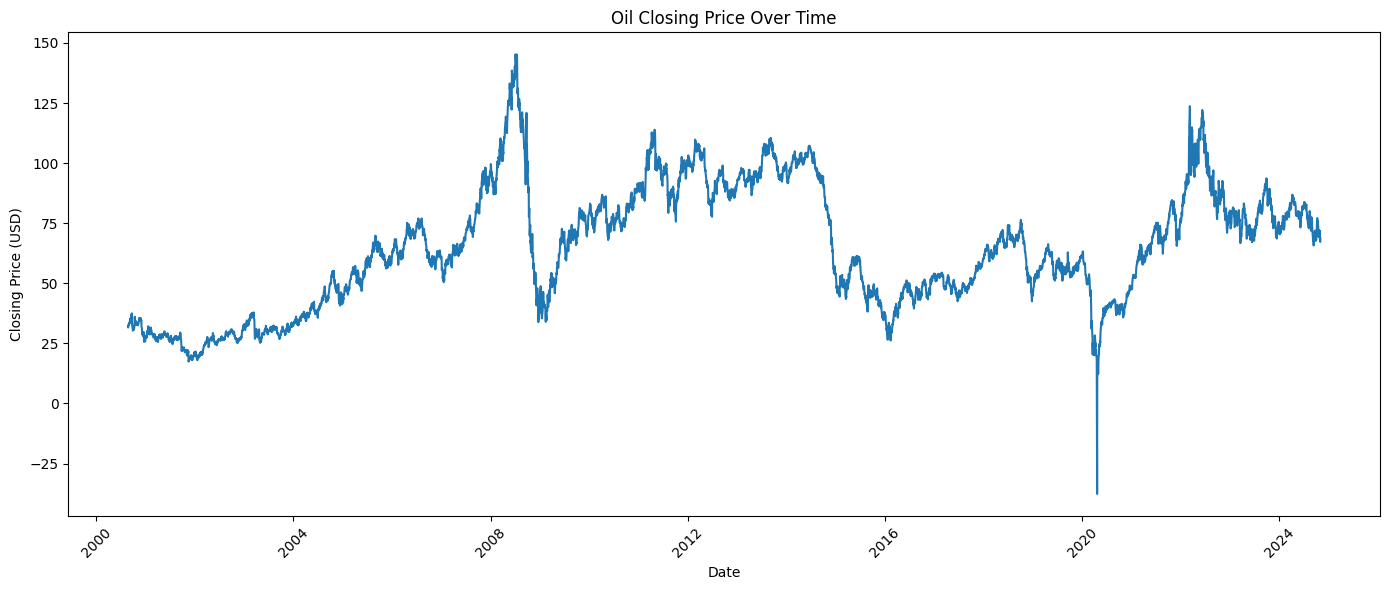

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'])
plt.title('Oil Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

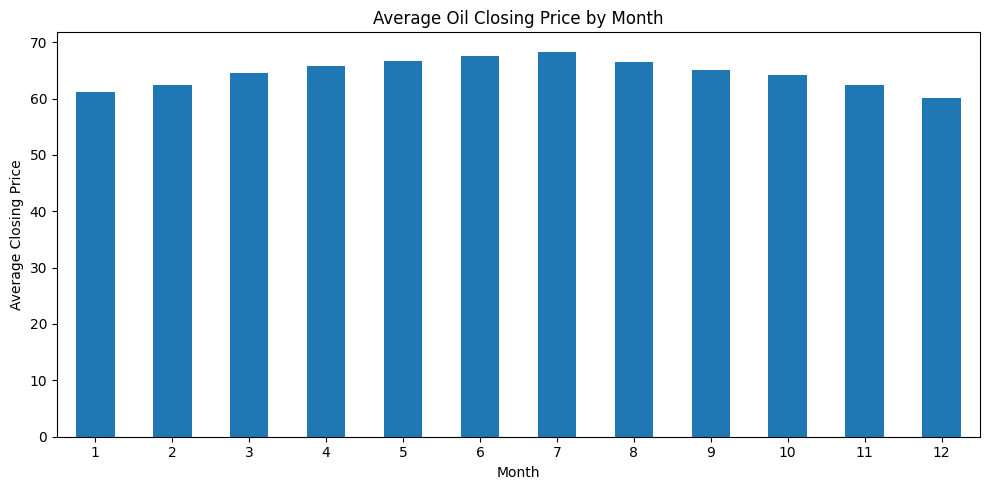

In [9]:
df['Month'] = df['Date'].dt.month
monthly_avg_prices = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(10, 5))
monthly_avg_prices.plot(kind='bar')
plt.title('Average Oil Closing Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Closing Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

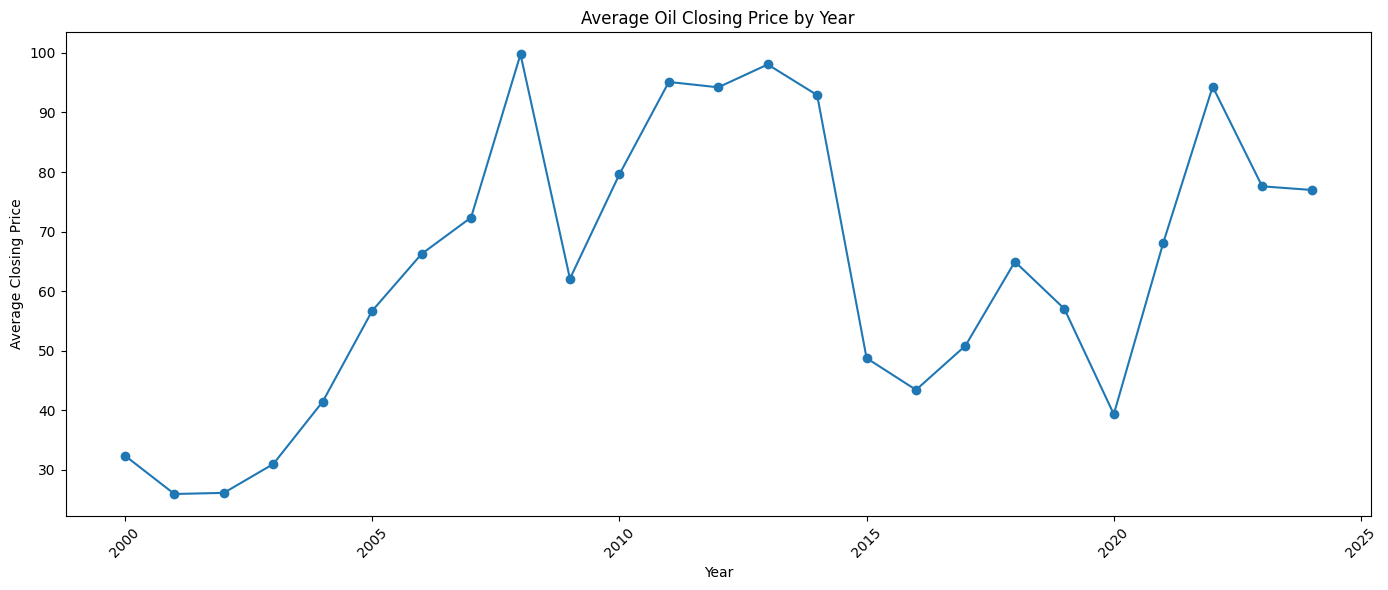

In [10]:
df['Year'] = df['Date'].dt.year
annual_avg_prices = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(14, 6))
annual_avg_prices.plot(marker='o')
plt.title('Average Oil Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

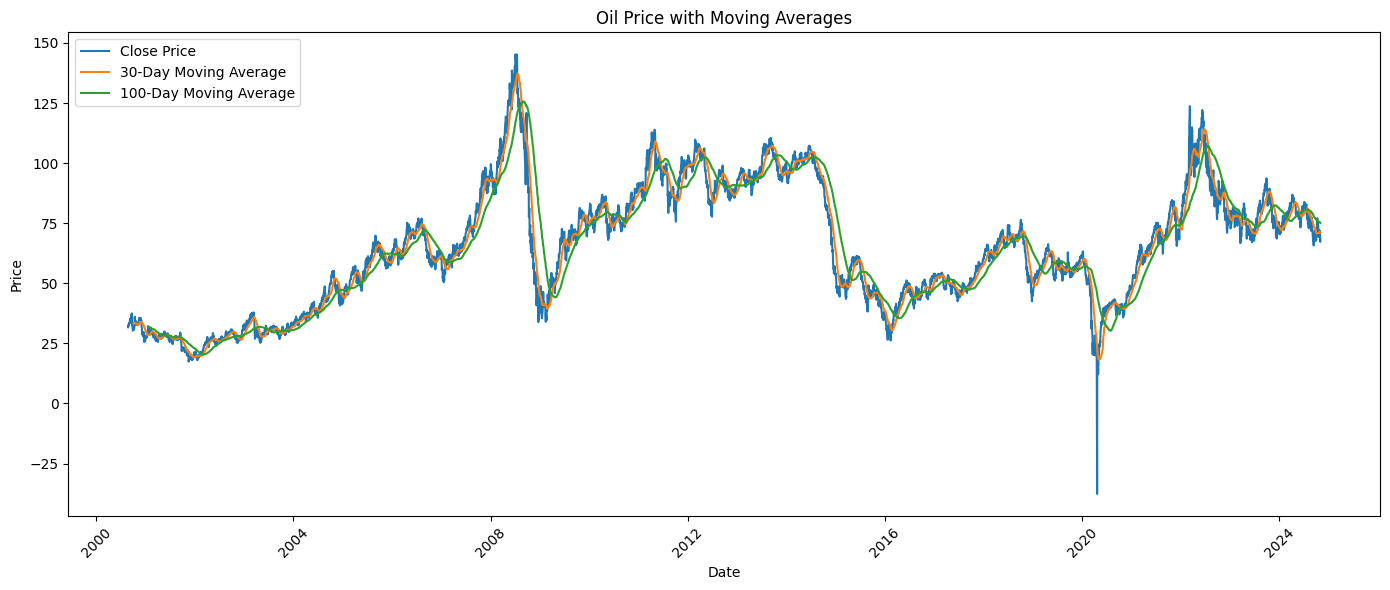

In [11]:
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA30'], label='30-Day Moving Average')
plt.plot(df['Date'], df['MA100'], label='100-Day Moving Average')
plt.title('Oil Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

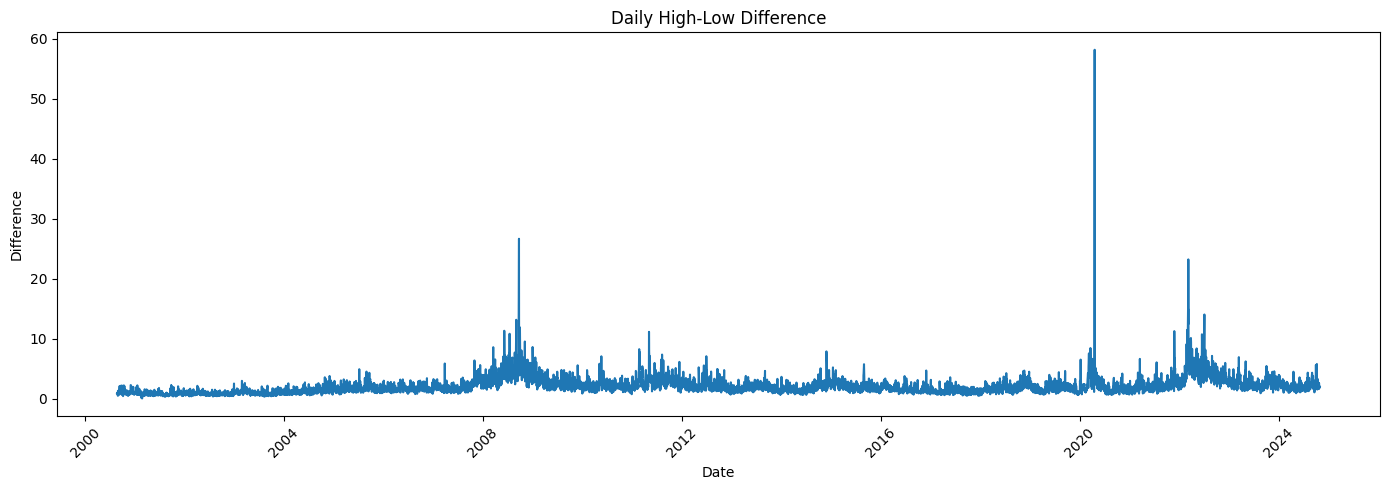

In [12]:
df['High_Low_Difference'] = df['High'] - df['Low']

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['High_Low_Difference'])
plt.title('Daily High-Low Difference')
plt.xlabel('Date')
plt.ylabel('Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Scaling and Sequence Creation

We will use only the **Close** price as the target variable and build sequences of the previous **60 days** to predict the next value.

To make the workflow more professional, the data is split into:
- **70% Train**
- **15% Validation**
- **15% Test**


In [13]:
# Use only the closing price for univariate forecasting
model_df = df[['Close']].copy()
time_step = 60

# Split indices
total_size = len(model_df)
train_size = int(total_size * 0.70)
val_size = int(total_size * 0.15)
test_size = total_size - train_size - val_size

train_values = model_df.iloc[:train_size].values
val_values = model_df.iloc[train_size - time_step: train_size + val_size].values
test_values = model_df.iloc[train_size + val_size - time_step:].values

# Fit scaler on training data only to reduce data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_values)
val_scaled = scaler.transform(val_values)
test_scaled = scaler.transform(test_values)

def create_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, time_step)
X_val, y_val = create_sequences(val_scaled, time_step)
X_test, y_test = create_sequences(test_scaled, time_step)

# Reshape for RNN-based models: [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Dates aligned with validation and test targets
val_dates = df['Date'].iloc[train_size:train_size + val_size].reset_index(drop=True)
test_dates = df['Date'].iloc[train_size + val_size:].reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4191, 60, 1)
X_val shape: (910, 60, 1)
X_test shape: (912, 60, 1)


## 5. Model Building Functions

In [14]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

## 6. Train the LSTM Model

In [15]:
lstm_model = build_lstm_model((X_train.shape[1], 1))
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0083 - val_loss: 9.4938e-04
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 9.3229e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 7.7595e-04
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0015 - val_loss: 6.9263e-04
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0015 - val_loss: 6.6126e-04
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 6.4033e-04
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 7.8861e-04
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 6.0993e-04
Epoch 10/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 9.8055e-04
Epoch 11/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0012 - val_loss: 6.4840e-04
E

In [17]:
# LSTM predictions
lstm_pred = lstm_model.predict(X_test)

# Inverse transform
lstm_pred_rescaled = scaler.inverse_transform(lstm_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
lstm_mae = mean_absolute_error(y_test_rescaled, lstm_pred_rescaled)
lstm_rmse = np.sqrt(mean_squared_error(y_test_rescaled, lstm_pred_rescaled))
lstm_r2 = r2_score(y_test_rescaled, lstm_pred_rescaled)

print("LSTM MAE :", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM R²  :", lstm_r2)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
LSTM MAE : 1.684248719064781
LSTM RMSE: 2.3011093612652687
LSTM R²  : 0.9636163197997767


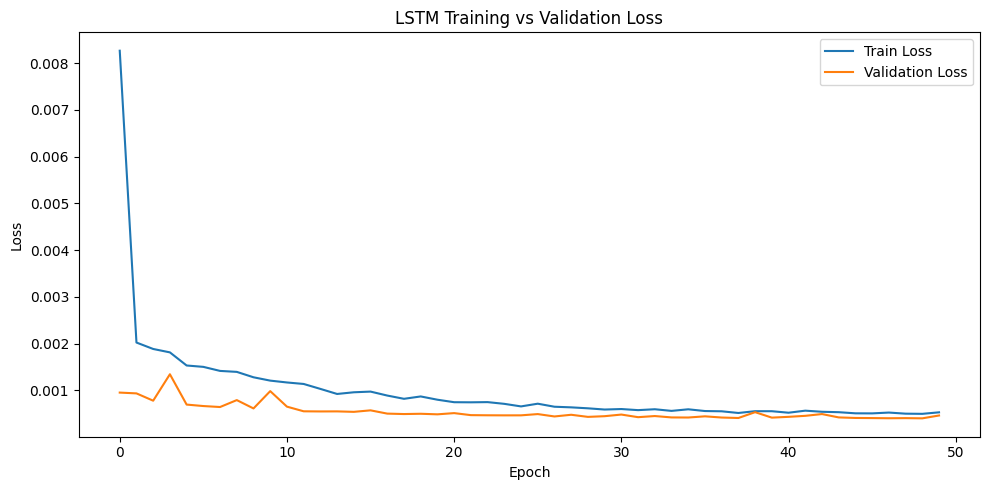

In [18]:
# LSTM training history
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

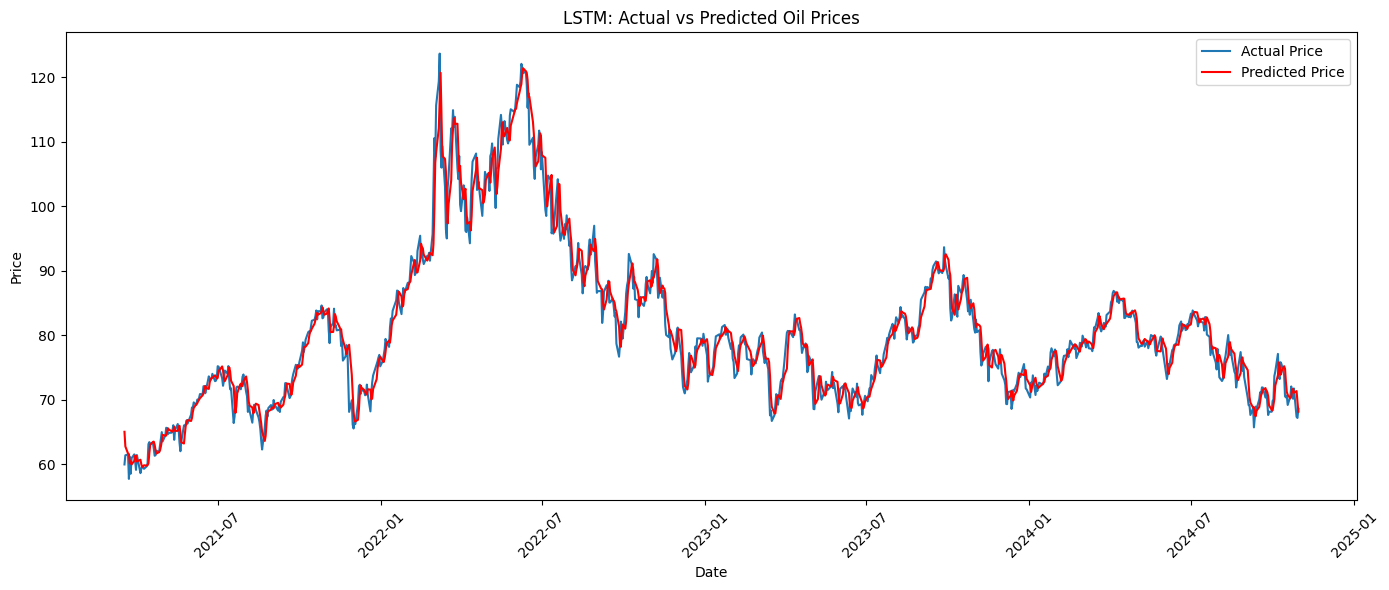

In [33]:
# LSTM actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_rescaled, label='Actual Price')
plt.plot(test_dates, lstm_pred_rescaled, label='Predicted Price' , color = "red" )
plt.title('LSTM: Actual vs Predicted Oil Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train the Simple RNN Model

In [21]:
rnn_model = build_rnn_model((X_train.shape[1], 1))
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0392 - val_loss: 0.0014
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0083 - val_loss: 6.9600e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0048 - val_loss: 6.9561e-04
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 5.3695e-04
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0030 - val_loss: 4.9982e-04
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 6.6044e-04
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 4.3541e-04
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 4.5515e-04


In [23]:
# RNN predictions
rnn_pred = rnn_model.predict(X_test)

# Inverse transform
rnn_pred_rescaled = scaler.inverse_transform(rnn_pred)

# Metrics
rnn_mae = mean_absolute_error(y_test_rescaled, rnn_pred_rescaled)
rnn_rmse = np.sqrt(mean_squared_error(y_test_rescaled, rnn_pred_rescaled))
rnn_r2 = r2_score(y_test_rescaled, rnn_pred_rescaled)

print("RNN MAE :", rnn_mae)
print("RNN RMSE:", rnn_rmse)
print("RNN R²  :", rnn_r2)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
RNN MAE : 3.342002144841404
RNN RMSE: 4.332263645862297
RNN R²  : 0.8710379690368666


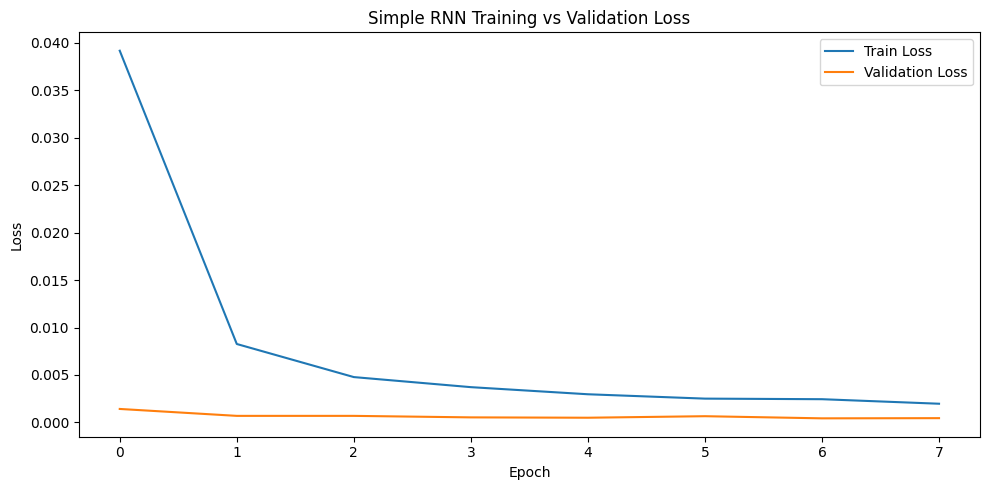

In [24]:
# RNN training history
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

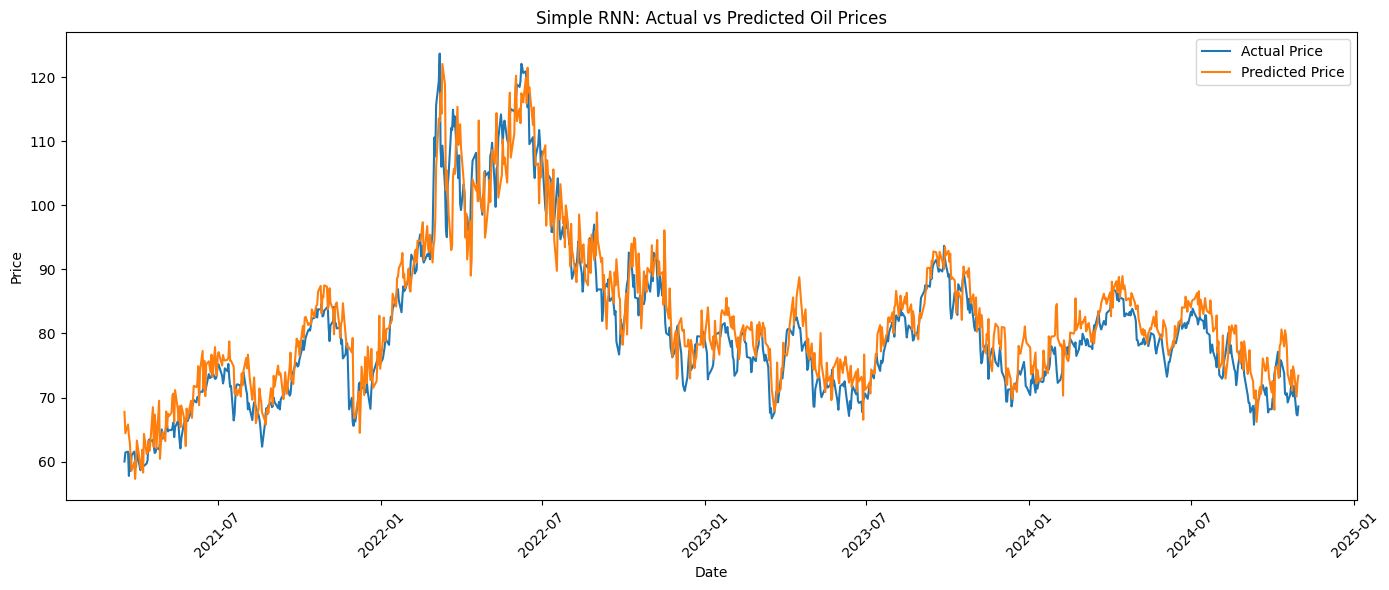

In [25]:
# RNN actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_rescaled, label='Actual Price')
plt.plot(test_dates, rnn_pred_rescaled, label='Predicted Price')
plt.title('Simple RNN: Actual vs Predicted Oil Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final Comparison Between LSTM and Simple RNN

In [27]:
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'Simple RNN'],
    'MAE': [lstm_mae, rnn_mae],
    'RMSE': [lstm_rmse, rnn_rmse],
    'R2': [lstm_r2, rnn_r2]
})

comparison_df

,Model,MAE,RMSE,R2
0,LSTM,1.684249,2.301109,0.963616
1,Simple RNN,3.342002,4.332264,0.871038


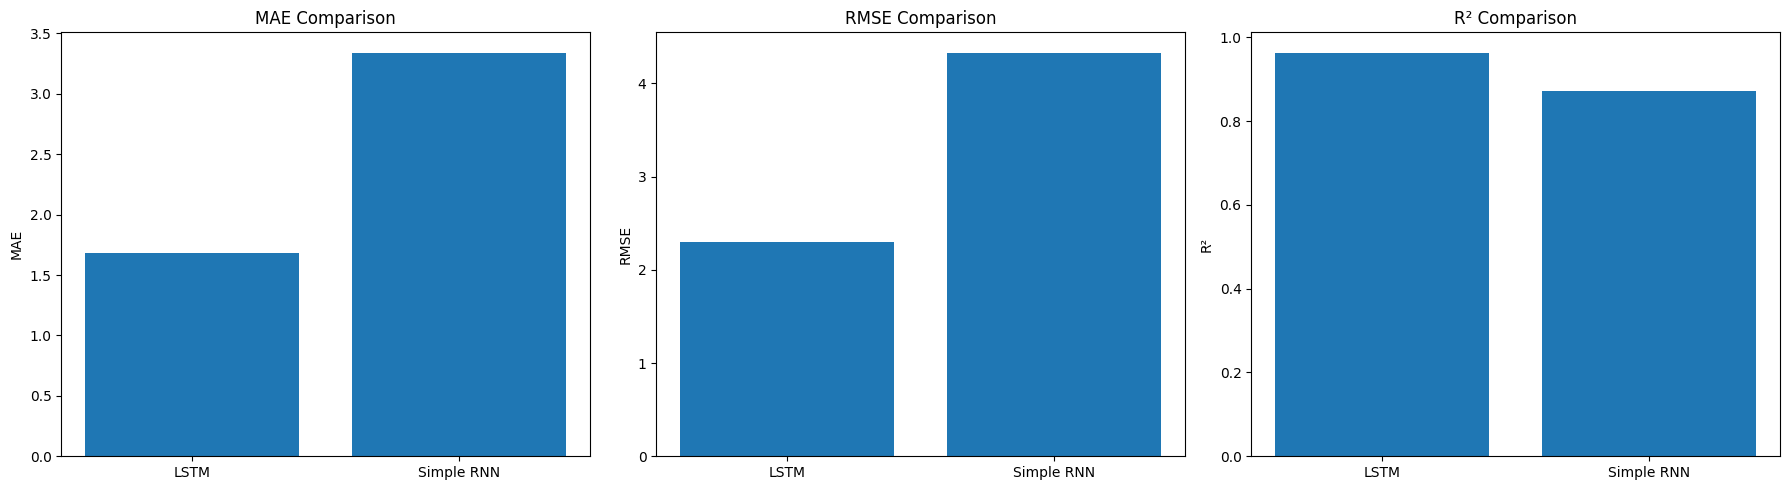

In [28]:
# Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(comparison_df['Model'], comparison_df['MAE'])
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')

axes[1].bar(comparison_df['Model'], comparison_df['RMSE'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

axes[2].bar(comparison_df['Model'], comparison_df['R2'])
axes[2].set_title('R² Comparison')
axes[2].set_ylabel('R²')

plt.tight_layout()
plt.show()

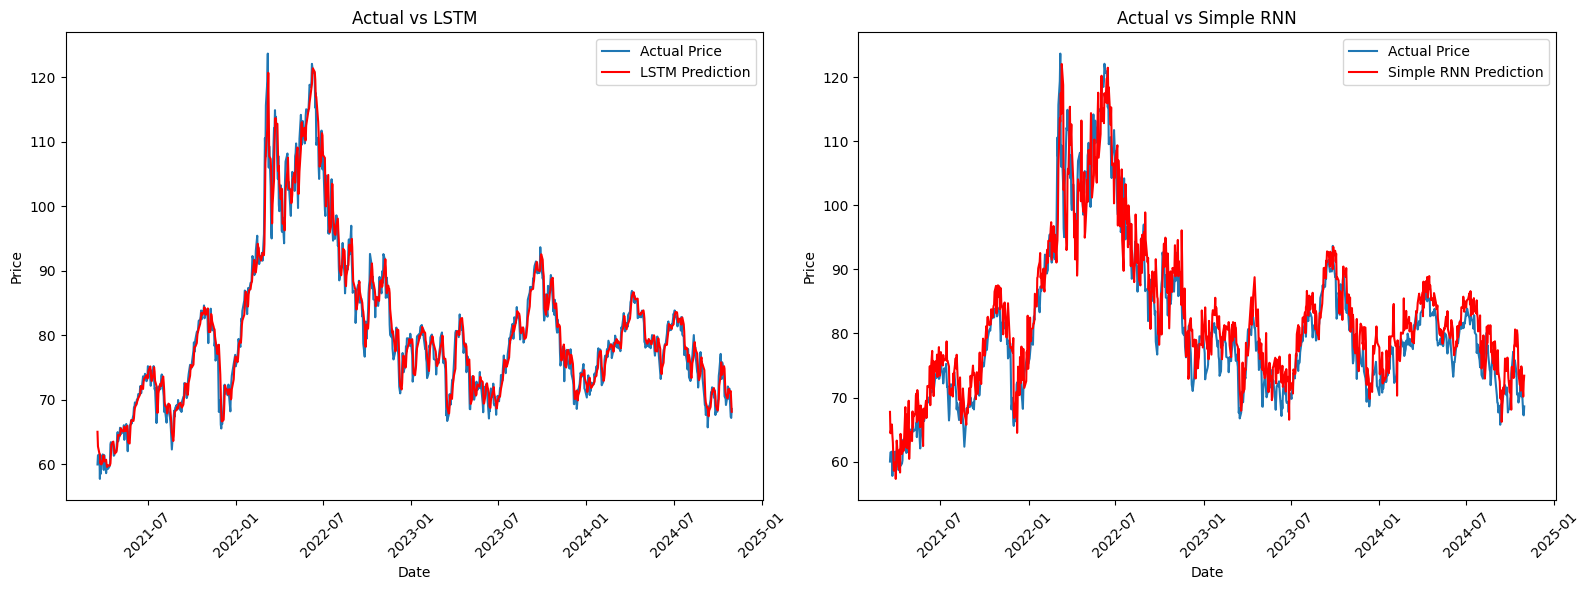

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs LSTM
axes[0].plot(test_dates, y_test_rescaled, label='Actual Price')
axes[0].plot(test_dates, lstm_pred_rescaled, label='LSTM Prediction' , color = "red")
axes[0].set_title('Actual vs LSTM')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Actual vs Simple RNN
axes[1].plot(test_dates, y_test_rescaled, label='Actual Price')
axes[1].plot(test_dates, rnn_pred_rescaled, label='Simple RNN Prediction' , color = "red")
axes[1].set_title('Actual vs Simple RNN')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# Print the best model based on RMSE
best_model_name = comparison_df.sort_values('RMSE').iloc[0]['Model']
best_model_rmse = comparison_df.sort_values('RMSE').iloc[0]['RMSE']

print(f"The best model based on RMSE is: {best_model_name}")
print(f"Best RMSE: {best_model_rmse:.4f}")

The best model based on RMSE is: LSTM
Best RMSE: 2.3011


## 9. Conclusion

After running the notebook, you can summarize the result like this:

- **LSTM** is usually stronger when the sequence dependency is more complex and long-term.
- **Simple RNN** is useful as a baseline but often struggles more with long-term dependencies.
- The final decision should be based on the **lowest MAE/RMSE** and the **highest R²** on the test set.

If LSTM achieves lower error values, then it is the better model for this oil price forecasting task.


In [36]:
lstm_model.save("oil_price_lstm_model.keras")
rnn_model.save("oil_price_simple_rnn_model.keras")